# Regressão - Previsão do valor de um ativo no dia seguinte

## Autores
- Felipe Bakowski Nantes de Souza  
- Vinicius Grecco Fonseca Mulato  
- Victor Soares

# 1.    Data set - Seleção

Usamos a biblioteca **yfinance** para baixar dados históricos de ações da Apple (AAPL) dos últimos 10 anos. O dataset contém dados diários de preços (abertura, máxima, mínima, fechamento) e volume negociado.

In [1]:
from scipy.stats import normaltest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
from mlp import mlp 

# baixar dados da Apple dos últimos 10 anos
df = yf.download("AAPL", period="10y", interval="1d", auto_adjust=True)
print("Shape:", df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (2515, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-10-26,25.906366,26.546834,25.825465,26.535599,265335200
2015-10-27,25.742313,26.189517,25.616466,25.933330,279537600
2015-10-28,26.803019,26.809762,26.081650,26.277162,342205600
2015-10-29,27.086176,27.122133,26.578296,26.674928,204909200
2015-10-30,26.854704,27.241232,26.843467,27.189545,197461200


In [2]:
# remover nível de ticker se presente (robusto)
if isinstance(df.columns, pd.MultiIndex):
    for lvl in range(df.columns.nlevels):
        # se a camada for constante (ex.: todos 'AAPL'), removemos essa camada
        if df.columns.get_level_values(lvl).nunique() == 1:
            df.columns = df.columns.droplevel(lvl)
            break
print("Columns after flattening:", df.columns.tolist())

Columns after flattening: ['Close', 'High', 'Low', 'Open', 'Volume']


# 2. Data set - Explicação

O `DataFrame` `df` reúne cotações diárias da Apple (ticker `AAPL`) obtidas via `yfinance` para os últimos 10 anos (`period="10y"`, `interval="1d"`). A coluna de índice (`Date`) marca cada pregão. A partir das séries básicas (`Open`, `High`, `Low`, `Close`, `Volume`) derivaram‑se as features abaixo:

- `Price_Range`: `High - Low`. Medida de volatilidade intraday.  
- `Price_Change`: `Close - Open`. Variação diária absoluta (momentum do dia).  
- `High_Low_Ratio`: `High / Low`. Proporção de amplitude do dia (volatilidade relativa).  
- `Return_1d`, `Return_3d`, `Return_5d`, `Return_10d`: retornos percentuais em janelas 1/3/5/10 dias. Capturam momentum em diferentes horizontes.  
- `MA_5`, `MA_10`, `MA_20`, `MA_50`: médias móveis do preço de fechamento (suavização de tendência).  
- `Volatility_5`, `Volatility_10`, `Volatility_20`: desvio padrão móvel do fechamento (risco/instabilidade em janelas distintas).  
- `Volume_MA_5`, `Volume_MA_10`: médias móveis do volume (interesse de mercado suavizado).  
- `BB_Middle`, `BB_Upper`, `BB_Lower`, `BB_Width`: bandas de Bollinger (MA_20 ± 2·Volatility_20) e largura (volatilidade implícita).  
- `RSI`: índice de força relativa (14 dias), indicador de sobrecompra/sobrevenda.  
- `MACD`, `MACD_Signal`, `MACD_Histogram`: MACD (EMA12−EMA26), sua linha de sinal (EMA9) e histograma (força do momentum).  
- `Momentum_5`, `Momentum_10`: diferença absoluta do fechamento em 5 e 10 dias (velocidade da variação).  
- `ROC_5`, `ROC_10`: rate of change (%) em 5 e 10 dias (retorno percentual em diferentes janelas).  
- `Target`: `Close.shift(-1)` — preço de fechamento do próximo dia (variável alvo).

Essas features procuram capturar preço, volume, volatilidade e momentum em múltiplas escalas temporais. O objetivo é treinar uma rede neural capaz de estimar o preço de fechamento (`Close`) do dia seguinte a partir desse histórico.

Ainda, vale notar que todos os dados (features + target) são numéricos continuos.

## Criação de novas features

In [3]:
print("\n CRIANDO FEATURES AVANÇADAS...")

# Features baseadas em preço
df['Price_Range'] = df['High'] - df['Low']  # Volatilidade intraday
df['Price_Change'] = df['Close'] - df['Open']  # Mudança diária
df['High_Low_Ratio'] = df['High'] / df['Low']  # Razão high/low

# Retornos percentuais
df['Return_1d'] = df['Close'].pct_change(1)  # Retorno de 1 dia
df['Return_3d'] = df['Close'].pct_change(3)  # Retorno de 3 dias
df['Return_5d'] = df['Close'].pct_change(5)  # Retorno de 5 dias
df['Return_10d'] = df['Close'].pct_change(10)  # Retorno de 10 dias

# Médias móveis
df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# Desvio padrão móvel (volatilidade)
df['Volatility_5'] = df['Close'].rolling(window=5).std()
df['Volatility_10'] = df['Close'].rolling(window=10).std()
df['Volatility_20'] = df['Close'].rolling(window=20).std()

# Média móvel do volume
df['Volume_MA_5'] = df['Volume'].rolling(window=5).mean()
df['Volume_MA_10'] = df['Volume'].rolling(window=10).mean()

# Bandas de Bollinger (simplificadas)
df['BB_Middle'] = df['MA_20']
df['BB_Upper'] = df['MA_20'] + 2 * df['Volatility_20']
df['BB_Lower'] = df['MA_20'] - 2 * df['Volatility_20']
df['BB_Width'] = df['BB_Upper'] - df['BB_Lower']

# RSI simplificado (Relative Strength Index)
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0).rolling(window=14).mean()
loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# MACD (Moving Average Convergence Divergence)
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']

# Features de momentum
df['Momentum_5'] = df['Close'] - df['Close'].shift(5)
df['Momentum_10'] = df['Close'] - df['Close'].shift(10)

# Rate of Change (ROC)
df['ROC_5'] = ((df['Close'] - df['Close'].shift(5)) / df['Close'].shift(5)) * 100
df['ROC_10'] = ((df['Close'] - df['Close'].shift(10)) / df['Close'].shift(10)) * 100

# Target: Preço de fechamento do próximo dia
df['Target'] = df['Close'].shift(-1)

print(f"Shape final após feature engineering: {df.shape}")
print(f"Total de features criadas: {df.shape[1] - 3}")  # -3 para Date, Close original e Target


 CRIANDO FEATURES AVANÇADAS...
Shape final após feature engineering: (2515, 34)
Total de features criadas: 31


## Crescimento da ação ao longo do tempo

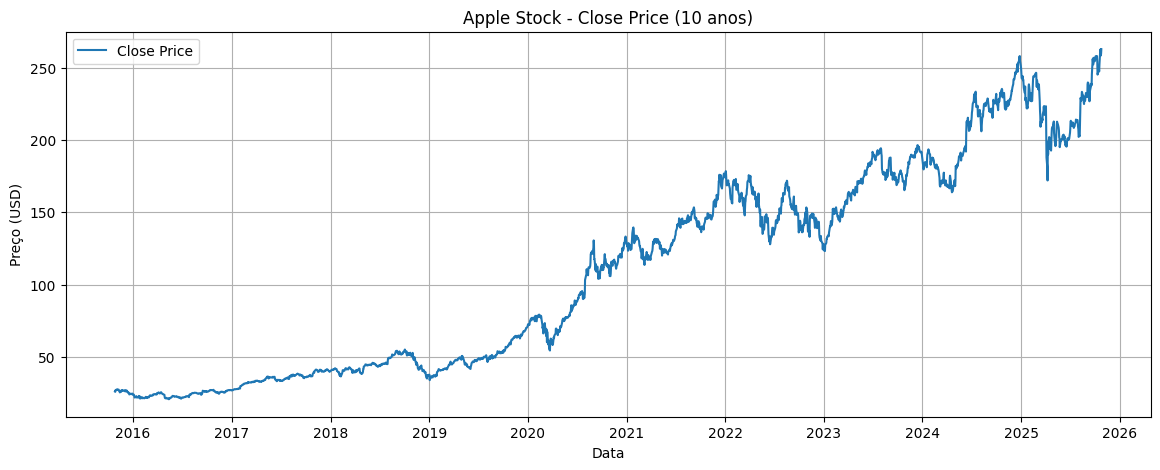

In [4]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title('Apple Stock - Close Price (10 anos)')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.legend()
plt.grid(True)
plt.show()

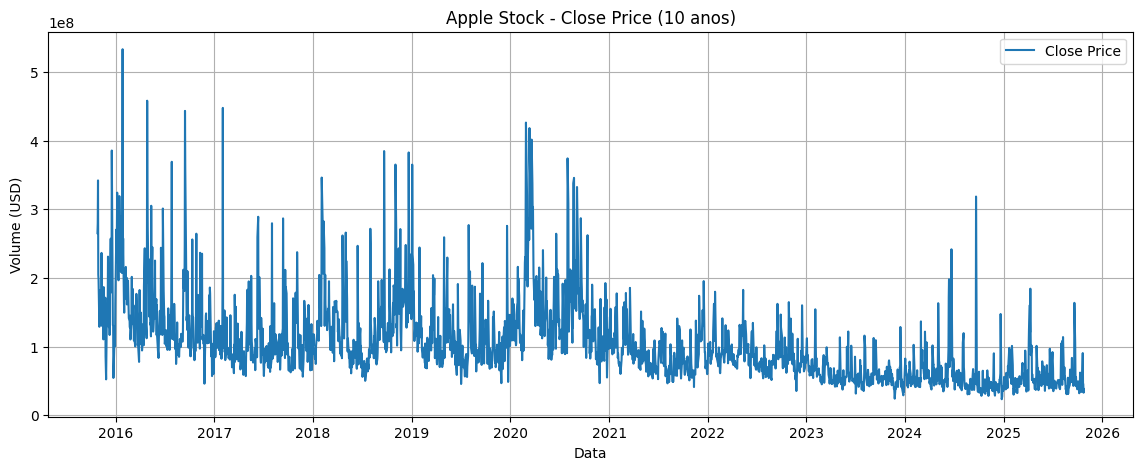

In [5]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Volume'], label='Close Price')
plt.title('Apple Stock - Close Price (10 anos)')
plt.xlabel('Data')
plt.ylabel('Volume (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Colunas com valores faltando

In [6]:
print("Valores faltantes por coluna:\n", df.isnull().sum())
df = df.dropna()

Valores faltantes por coluna:
 Price
Close              0
High               0
Low                0
Open               0
Volume             0
Price_Range        0
Price_Change       0
High_Low_Ratio     0
Return_1d          1
Return_3d          3
Return_5d          5
Return_10d        10
MA_5               4
MA_10              9
MA_20             19
MA_50             49
Volatility_5       4
Volatility_10      9
Volatility_20     19
Volume_MA_5        4
Volume_MA_10       9
BB_Middle         19
BB_Upper          19
BB_Lower          19
BB_Width          19
RSI               13
MACD               0
MACD_Signal        0
MACD_Histogram     0
Momentum_5         5
Momentum_10       10
ROC_5              5
ROC_10            10
Target             1
dtype: int64


In [7]:
print("Valores faltantes por coluna:\n", df.isnull().sum())

Valores faltantes por coluna:
 Price
Close             0
High              0
Low               0
Open              0
Volume            0
Price_Range       0
Price_Change      0
High_Low_Ratio    0
Return_1d         0
Return_3d         0
Return_5d         0
Return_10d        0
MA_5              0
MA_10             0
MA_20             0
MA_50             0
Volatility_5      0
Volatility_10     0
Volatility_20     0
Volume_MA_5       0
Volume_MA_10      0
BB_Middle         0
BB_Upper          0
BB_Lower          0
BB_Width          0
RSI               0
MACD              0
MACD_Signal       0
MACD_Histogram    0
Momentum_5        0
Momentum_10       0
ROC_5             0
ROC_10            0
Target            0
dtype: int64


Foi aplicado o método **`dropna()`** para remover as linhas com valores ausentes, pois algumas **features derivadas** (como *Momentum5*, *MA_5*, *Volatility_10*, *Return_10d*, etc.) apresentam valores faltantes nas primeiras observações.

Por exemplo, o cálculo do **Momentum5** requer os cinco dias anteriores; portanto, **as quatro primeiras linhas não têm valor definido** e retornam *NaN*. O mesmo ocorre para outros indicadores que utilizam períodos maiores (como *MA_20* ou *Return_10d*).



## Visualizando as features

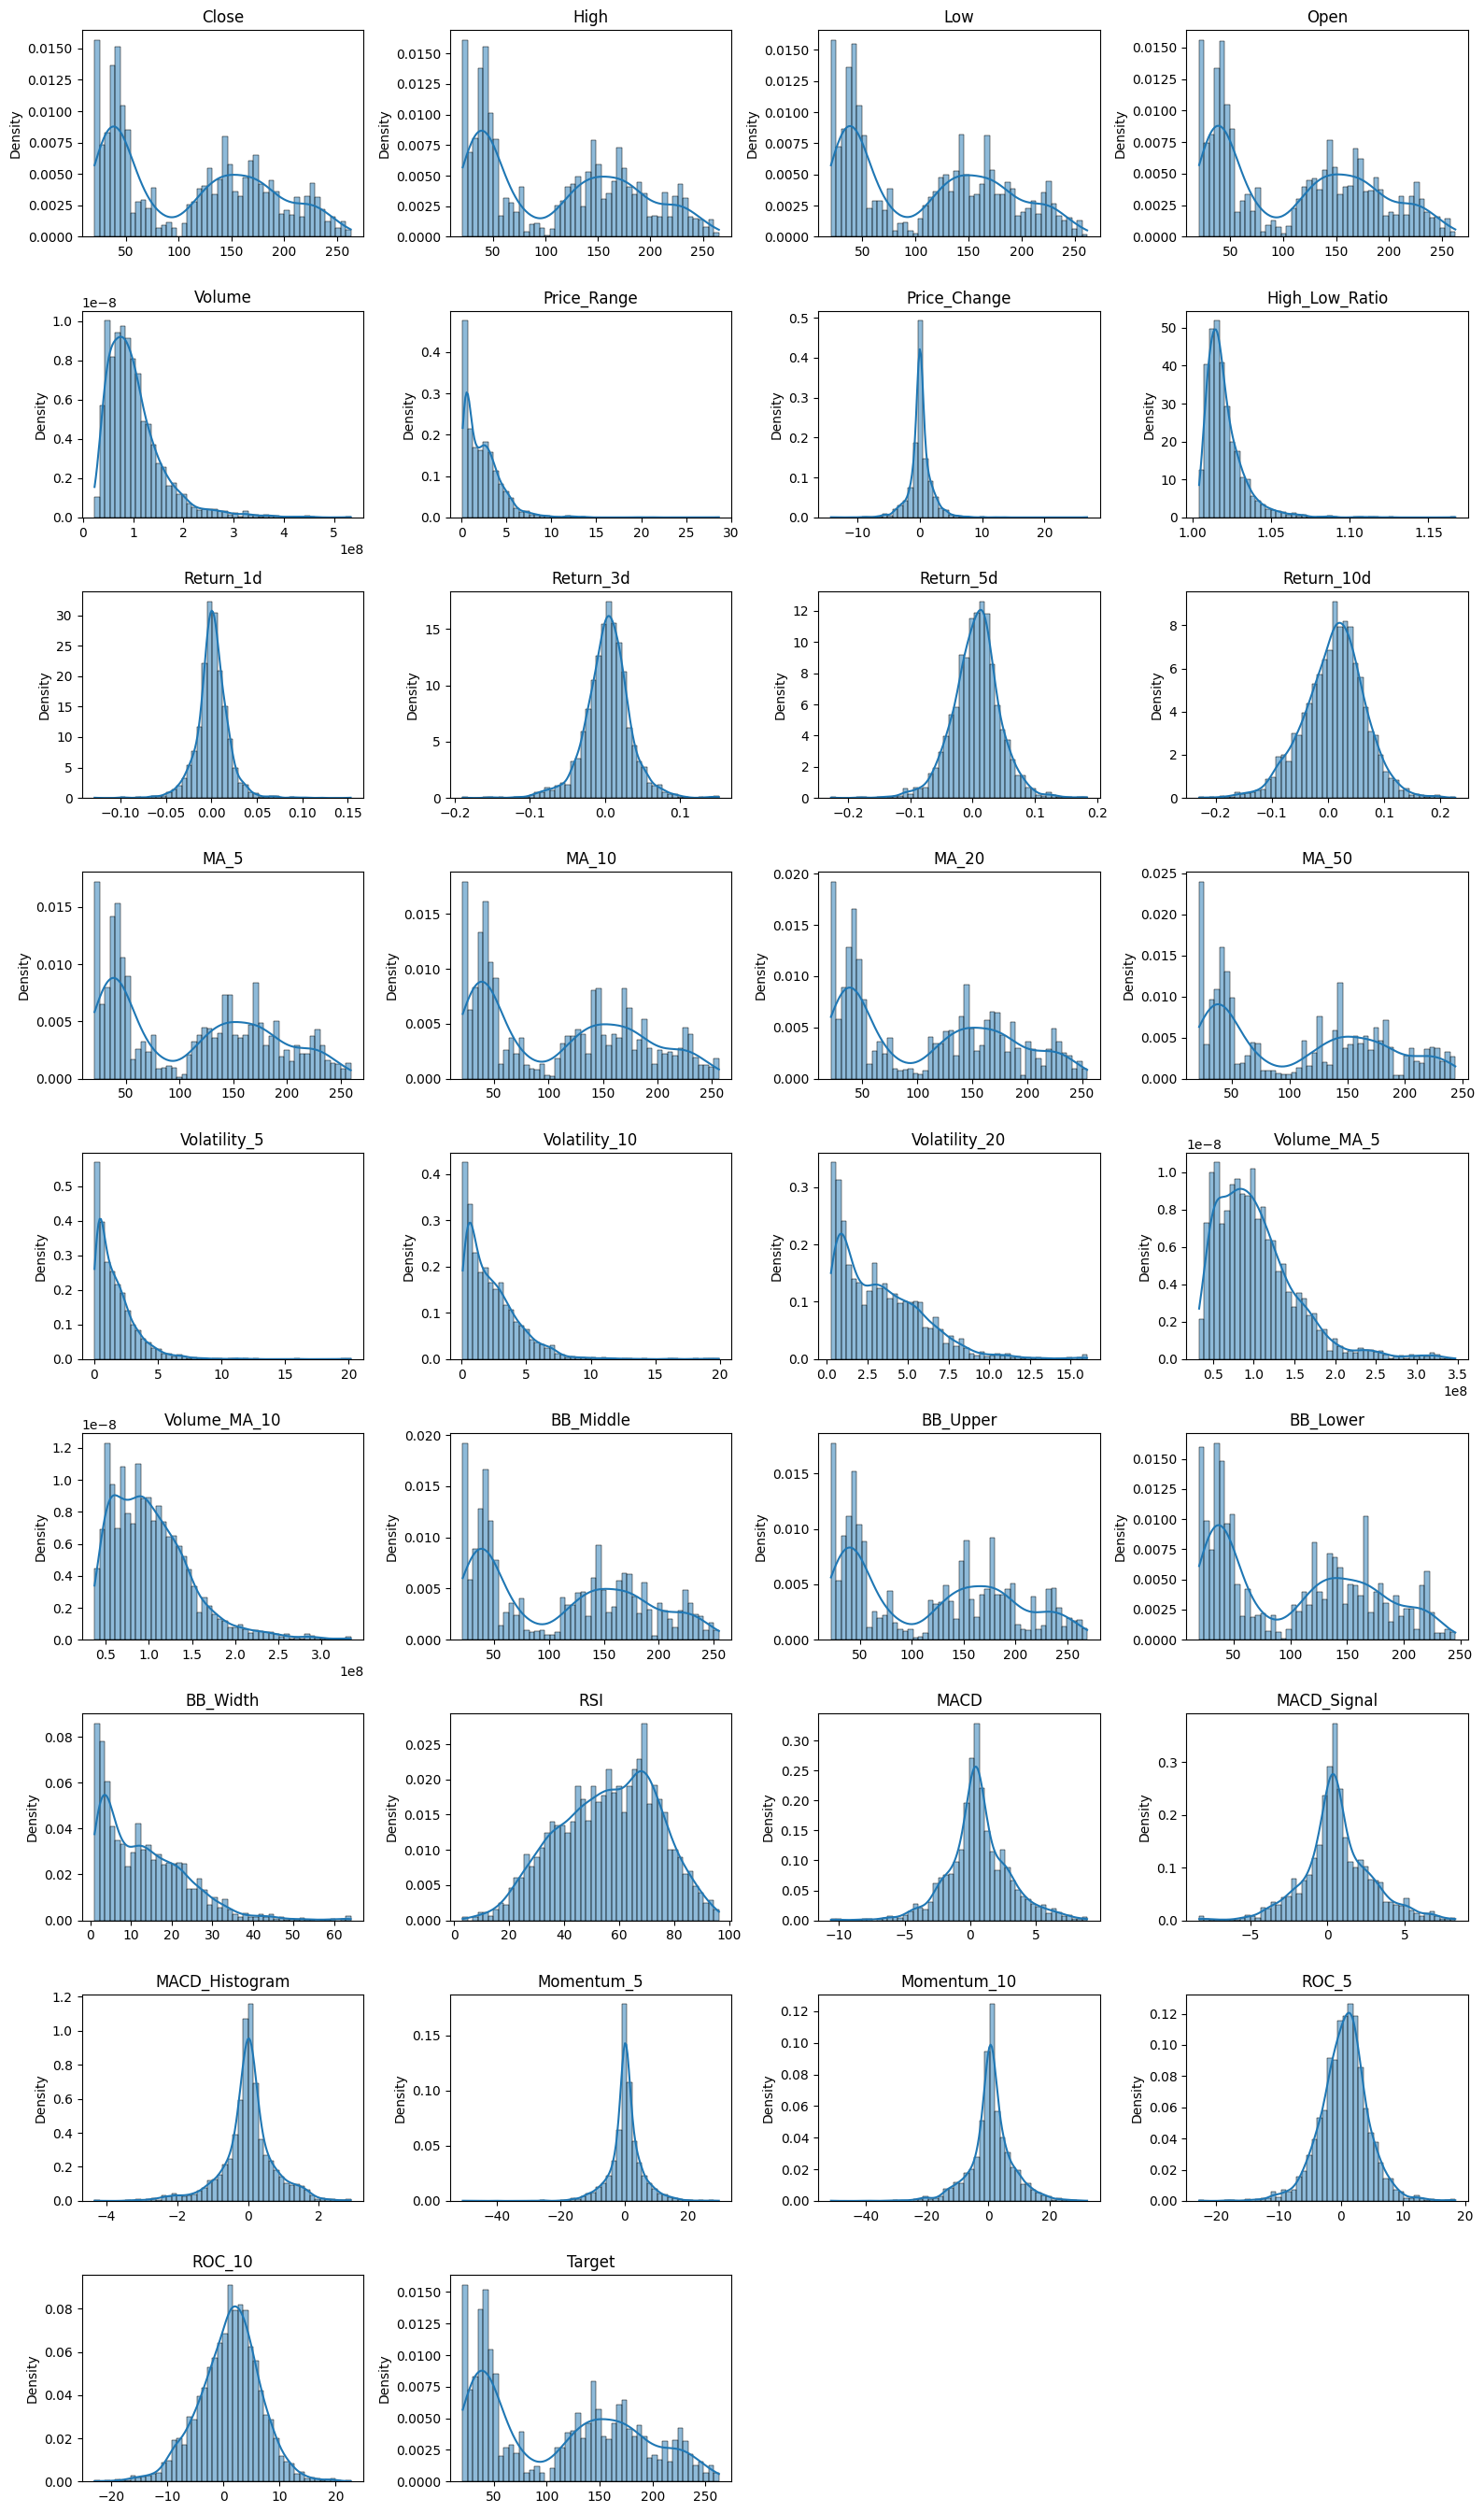

In [8]:
# Configura grid de subplots
n_cols = 4
n_features = len(df.columns)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes[i]
    # remove NaNs antes de plotar
    data = df[col].dropna()
    if data.size == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(col)
        ax.set_axis_off()
        continue
    sns.histplot(data, bins=50, kde=True, ax=ax, stat='density', color='tab:blue')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Density')

# Desativa eixos extras se houver
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

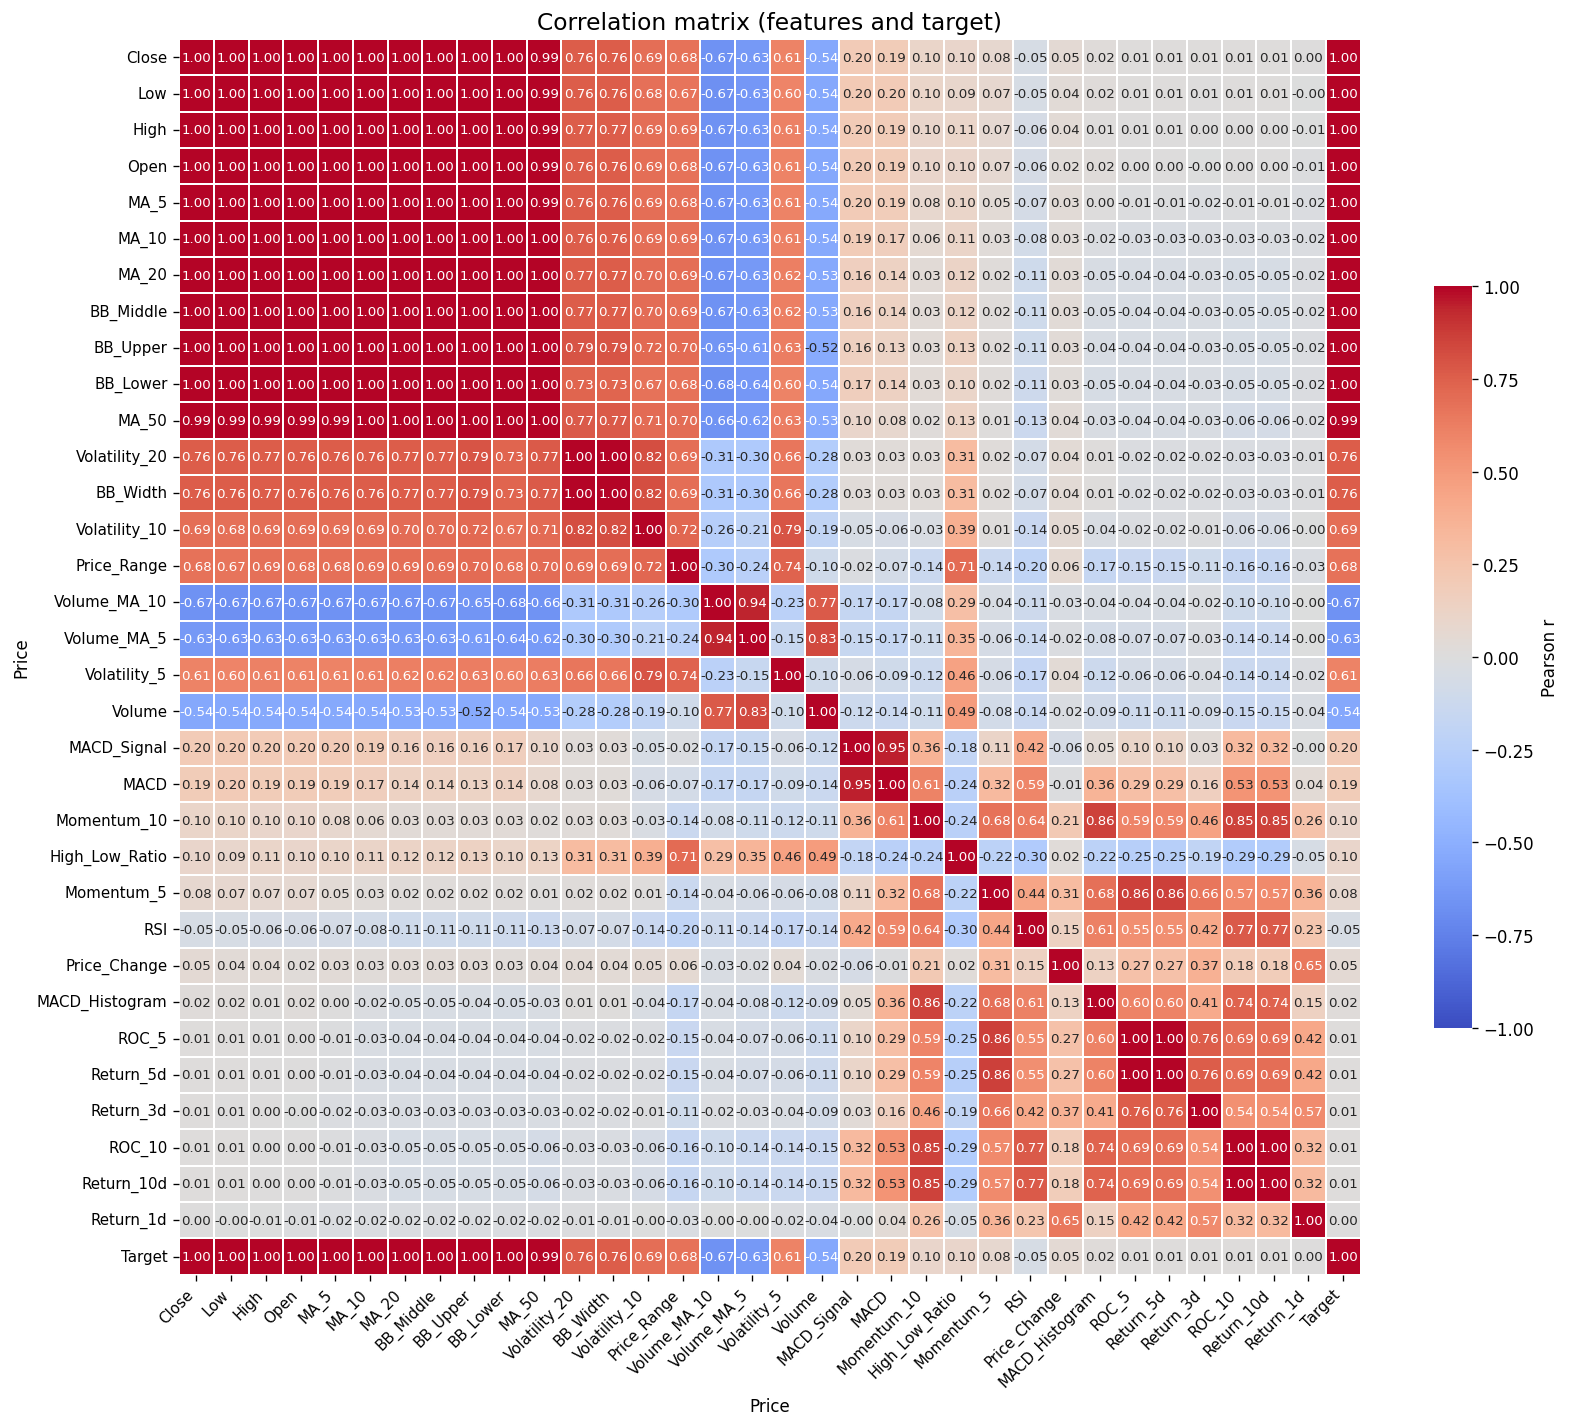


Top features por correlação (com sinal) com Target:


,corr_with_target
Price,
Close,0.999
Low,0.999
High,0.999
Open,0.999
MA_5,0.999
MA_10,0.998
MA_20,0.997
BB_Middle,0.997
BB_Upper,0.996



Média e desvio padrão das variáveis numéricas:


,mean,std
Price,,
Close,111.4397,70.6981
High,112.5500,71.3794
Low,110.2107,69.9294
Open,111.3314,70.6237
Volume,102733762.8398,57807883.1952
Price_Range,2.3393,2.1404
Price_Change,0.1083,1.9299
High_Low_Ratio,1.0205,0.0126
Return_1d,0.0012,0.0184


In [9]:
pd.options.display.float_format = '{:.3f}'.format

corr_df = df.corr()

order = corr_df['Target'].abs().sort_values(ascending=False).index.tolist()
# opcional: colocar o target no final para melhor leitura
order = [c for c in order if c != 'Target'] + ['Target']
corr_df = corr_df.loc[order, order]

# Plot heatmap com layout melhorado
plt.figure(figsize=(14, 12), dpi=120)
sns.heatmap(
    corr_df,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size':8},
    linewidths=0.25,
    cbar_kws={'shrink':0.6, 'label':'Pearson r'}
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title('Correlation matrix (features and target)', fontsize=14)
plt.tight_layout()
plt.show()

top = corr_df['Target'].drop(index='Target').sort_values(key=lambda s: s.abs(), ascending=False)
print('\nTop features por correlação (com sinal) com Target:')
display(top.to_frame(name='corr_with_target'))

# Estatísticas descritivas: média e desvio padrão
stats = df.agg(['mean', 'std']).T
stats = stats.rename(columns={'mean':'mean','std':'std'})
print('\nMédia e desvio padrão das variáveis numéricas:')
display(stats.style.format('{:.4f}'))

# 3. Limpeza & Normalização

### Abordagem geral

Antes de aplicar qualquer técnica de normalização, é essencial **verificar a distribuição dos dados**. A escolha entre **normalização Z-score** ou **Min-Max** depende diretamente da **normalidade** da variável analisada.

1. **Teste de normalidade:**
   Aplicamos o **teste de D’Agostino e Pearson** para avaliar se a variável segue uma distribuição normal.

   * **p-valor alto (p > 0,05):** não há evidências para rejeitar a hipótese de normalidade → aplicar **Z-score**.
   * **p-valor baixo (p ≤ 0,05):** rejeita-se a hipótese de normalidade → aplicar **Min-Max**.




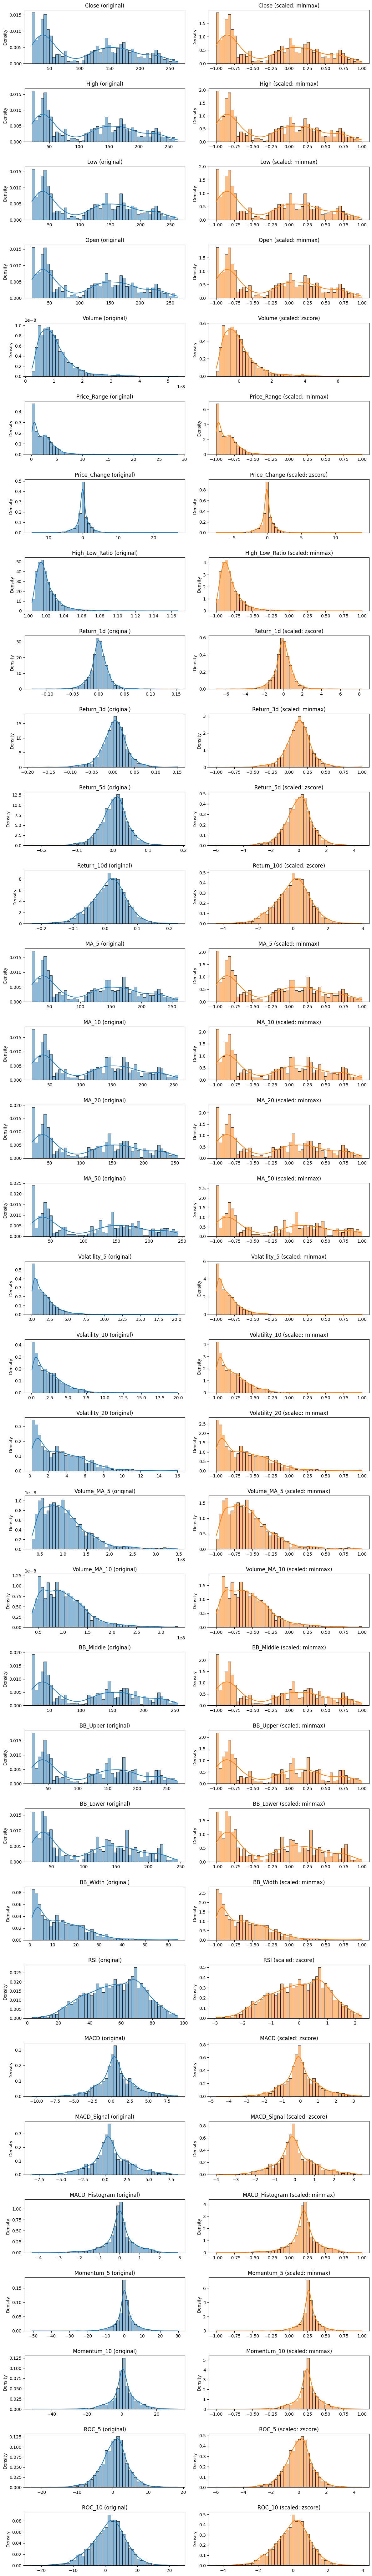

In [10]:
alpha = 0.02

df_orig = df.copy()

# decidir tipo de scaler usando uma amostra do dataset inteiro
sample = df.sample(n=min(1000, len(df)), random_state=42)

applied = {}

for col in df.columns:
    if col != 'Target':
        vals_sample = sample[col].values.reshape(-1, 1).astype(float)

        stat, p = normaltest(vals_sample[:100].ravel())

        if p >= alpha:
            scaler = StandardScaler()
            choice = "zscore"
        else:
            scaler = MinMaxScaler(feature_range=(-1,1))
            choice = "minmax"

        df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1)).ravel()

        applied[col] = choice

cols = list(df.columns)
n_features = len(cols)-1


fig, axes = plt.subplots(n_features, 2, figsize=(12, 2.5 * n_features))
axes = np.atleast_2d(axes)

for i, c in enumerate(cols):
    if c != "Target":
        ax_orig = axes[i, 0]
        ax_scaled = axes[i, 1]

        data_orig = df_orig[c]
        data_scaled = df[c]

        # plot original
        sns.histplot(data_orig, bins=50, kde=True, ax=ax_orig, stat="density", color="tab:blue")
        ax_orig.set_title(f"{c} (original)")
        ax_orig.set_xlabel("")
        ax_orig.set_ylabel("Density")

        # plot scaled
        sns.histplot(data_scaled, bins=50, kde=True, ax=ax_scaled, stat="density", color="tab:orange")
        choice_label = applied.get(c, "?")
        ax_scaled.set_title(f"{c} (scaled: {choice_label})")
        ax_scaled.set_xlabel("")
        ax_scaled.set_ylabel("Density")

plt.tight_layout()
plt.show()


# 4. Implementação MLP


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class mlp:
    def __init__(self, n_features:int, n_hidden_layers: int, n_neurons_per_layer: list, 
                activation: str, loss: str, optimizer: str, epochs: int, eta: float) -> None:
        self.n_features = n_features
        self.n_hidden_layers = n_hidden_layers
        self.n_neurons_per_layer = n_neurons_per_layer
        self.activation = activation
        self.loss = loss
        self.optimizer = optimizer
        self.epochs = epochs
        self.eta = eta

        self.weights = []
        self.biases = []
        self.layer_dims = [n_features] + n_neurons_per_layer

        for i in range(len(self.layer_dims) - 1):
            w = np.random.randn(self.layer_dims[i+1], self.layer_dims[i]) * 0.1
            b = np.zeros((self.layer_dims[i+1],))
            self.weights.append(w)
            self.biases.append(b)

        # histórico de treino
        self.metric_name = "Accuracy" if loss == "cross_entropy" else "RMSE"
        self.history = {"loss": [], "metric": []}

        print("\n=== Inicialização de Pesos e Biases ===")
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            print(f"Camada {i+1}:")
            print(f"W{i+1} shape {w.shape}:\n{w}")
            print(f"b{i+1} shape {b.shape}:\n{b}\n")

    def train(self, X, y, threshold: float = 5e-3, window: int = 10) -> None:
        loss_history = []

        for epoch in range(self.epochs):
            total_loss = 0
            for i in range(len(y)):
                y_pred, cache = self.forward_pass(X[i])
                loss = self.loss_calculation(y[i], y_pred)
                total_loss += loss
                grads_w, grads_b = self.backpropagation(y[i], y_pred, cache)
                self.update_parameters(grads_w, grads_b)

            avg_loss = total_loss / len(y)
            loss_history.append(avg_loss)

            preds_train = self.test(X)
            if self.loss == "cross_entropy":
                train_metric = self.calculate_accuracy(y, preds_train)
            else:
                train_metric = self.calculate_rmse(y, preds_train)

            # armazenar no histórico
            self.history["loss"].append(avg_loss)
            self.history["metric"].append(train_metric)

            if epoch % 10 == 0:
                if self.loss == "cross_entropy":
                    metric_str = f"{train_metric*100:.2f}%" if not np.isnan(train_metric) else "nan"
                else:
                    metric_str = f"{train_metric:.6f}"
                print(f"Epoch {epoch}, Loss: {avg_loss:.6f}, Train {self.metric_name}: {metric_str}")

            # critério de parada: média móvel dos últimos "window" epochs
            if epoch >= window:
                moving_avg_prev = np.mean(loss_history[-2*window:-window])
                moving_avg_curr = np.mean(loss_history[-window:])
                if abs(moving_avg_prev - moving_avg_curr) < threshold:
                    print(f"Treinamento encerrado no epoch {epoch} (convergência detectada).")
                    break

    def test(self, X: np.ndarray) -> np.ndarray:
        preds = []
        for i in range(len(X)):
            y_pred, _ = self.forward_pass(X[i])
            if self.loss == "cross_entropy":
                preds.append(np.argmax(y_pred))
            else:
                val = np.array(y_pred).ravel()
                preds.append(val[0] if val.size > 0 else val)
        return np.array(preds)


    def evaluate(self, X: np.ndarray, y: np.ndarray, plot_confusion: bool, plot_roc: bool, preds: np.ndarray):
        if self.loss == "cross_entropy":
            acc = self.calculate_accuracy(y, preds)
            print(f"Accuracy: {acc*100:.2f}%")
            report = {"accuracy": acc}
            self.last_classification_report = report
        else:
            y_true = np.asarray(y).ravel()
            preds = np.asarray(preds).ravel()
            metrics = self._compute_regression_metrics(y_true, preds)

            baseline_preds = np.full_like(y_true, y_true.mean())
            baseline_metrics = self._compute_regression_metrics(y_true, baseline_preds)

            self._print_regression_summary(metrics, baseline_metrics)

            report = {
                "metrics": metrics,
                "baseline_metrics": baseline_metrics,
                "residuals": y_true - preds,
                "y_true": y_true,
                "y_pred": preds,
            }
            self.last_regression_report = report

        print("\n=== Pesos e Biases do Modelo ===")
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            print(f"\nCamada {i+1}:")
            print(f"  Pesos W{i+1} (shape {w.shape}):")
            print(w)
            print(f"  Biases b{i+1} (shape {b.shape}):")
            print(b)

        binary = (len(np.unique(y)) == 2)

        if plot_confusion and self.loss == "cross_entropy":
            self.plot_confusion_matrix(y, preds)
        elif plot_confusion:
            print("Confusion matrix não é aplicável para regressão.")

        if plot_roc and binary and self.loss == "cross_entropy":
            self.plot_roc_curve(X, y)
        elif plot_roc and self.loss != "cross_entropy":
            print("ROC curve não é aplicável para regressão.")

        # sempre plota histórico se existir
        if self.history and len(self.history.get("loss", [])) > 0:
            self.plot_history()

        return report

    # -------- Funções auxiliares de plot --------
    def plot_confusion_matrix(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

        plt.figure(figsize=(6,5))
        sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                    xticklabels=np.unique(y_true),
                    yticklabels=np.unique(y_true))
        plt.title("Confusion Matrix (normalized by row)")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

    def plot_roc_curve(self, X, y_true):
        y_scores = []
        for i in range(len(X)):
            y_pred, _ = self.forward_pass(X[i])
            if self.loss == "cross_entropy":
                y_scores.append(y_pred[1])
            else:
                val = np.array(y_pred).ravel()
                y_scores.append(val[0] if val.size > 0 else val)
        y_scores = np.array(y_scores)

        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, color="darkorange", lw=2,
                 label=f"ROC curve (area = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic (ROC)")
        plt.legend(loc="lower right")
        plt.show()

    def plot_history(self):
        """Plota loss e accuracy armazenados em self.history."""
        loss = self.history.get("loss", [])
        metric = self.history.get("metric", [])
        epochs = np.arange(1, len(loss)+1)

        fig, axes = plt.subplots(1, 2, figsize=(12,4))
        # loss
        axes[0].plot(epochs, loss, marker="o")
        axes[0].set_title("Loss por Epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True, linestyle="--", alpha=0.4)
        # accuracy
        axes[1].plot(epochs, metric, marker="o")
        axes[1].set_title(f"{self.metric_name} por Epoch (treino)")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(self.metric_name)
        axes[1].grid(True, linestyle="--", alpha=0.4)

        plt.tight_layout()
        plt.show()

    def calculate_accuracy(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return np.mean(y_true == y_pred)

    def calculate_rmse(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_true = np.asarray(y_true).ravel()
        y_pred = np.asarray(y_pred).ravel()
        return np.sqrt(np.mean((y_true - y_pred)**2))

    def _compute_regression_metrics(self, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
        y_true = np.asarray(y_true).ravel()
        y_pred = np.asarray(y_pred).ravel()

        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        r2 = r2_score(y_true, y_pred)

        return {
            "MAE": mae,
            "MAPE (%)": mape,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2,
        }

    def _print_regression_summary(self, model_metrics: dict, baseline_metrics: dict) -> None:
        header = f"{'Metric':<12}{'Model':>14}{'Baseline':>14}"
        print("\nRegression metrics (model vs. mean baseline):")
        print(header)
        print("-" * len(header))
        for key in ["MAE", "MAPE (%)", "MSE", "RMSE", "R2"]:
            model_val = model_metrics.get(key, float("nan"))
            baseline_val = baseline_metrics.get(key, float("nan"))
            print(f"{key:<12}{model_val:>14.6f}{baseline_val:>14.6f}")

    def forward_pass(self, x: np.ndarray) -> tuple:
        a = x
        cache = {"z": [], "a": [a]}
        for i in range(len(self.weights)):
            z = np.dot(self.weights[i], a) + self.biases[i]
            if i == len(self.weights) - 1 and self.loss == "cross_entropy":
                a = self.softmax(z)
            else:
                a = self.activation_function(z)
            cache["z"].append(z)
            cache["a"].append(a)
        return a, cache

    def backpropagation(self, y_true: np.ndarray, y_pred: np.ndarray, cache: dict) -> tuple:
        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)

        # Última camada
        if self.loss == "cross_entropy":
            delta = self.derive_cross_entropy(y_true, y_pred)
        elif self.loss == "mse":
            dloss_dy_pred = self.derive_mse(y_true, y_pred)
            if self.activation == "sigmoid":
                delta = dloss_dy_pred * self.derive_sigmoid(cache["z"][-1])
            elif self.activation == "tanh":
                delta = dloss_dy_pred * self.derive_tanh(cache["z"][-1])
            elif self.activation == "relu":
                delta = dloss_dy_pred * self.derive_relu(cache["z"][-1])
        else:
            raise ValueError("Loss não suportada")

        grads_w[-1] = np.outer(delta, cache["a"][-2])
        grads_b[-1] = delta

        # Camadas ocultas
        # não faz sentido atualizar delta em "a", já que só faz sentido atualizar os pesos, que estão na pré ativação "z"
        for l in reversed(range(len(self.weights)-1)):
            delta = np.dot(self.weights[l+1].T, delta)
            if self.activation == "sigmoid":
                delta *= self.derive_sigmoid(cache["z"][l])
            elif self.activation == "tanh":
                delta *= self.derive_tanh(cache["z"][l])
            elif self.activation == "relu":
                delta *= self.derive_relu(cache["z"][l])
            grads_w[l] = np.outer(delta, cache["a"][l]) # o primeiro x esta dentro do cache "a"
            grads_b[l] = delta

        return grads_w, grads_b
        
    def update_parameters(self, grads_w, grads_b):
        if self.optimizer == "gd":
            for i in range(len(self.weights)):
                self.weights[i] -= self.eta * grads_w[i]
                self.biases[i]  -= self.eta * grads_b[i]
        else:
            raise ValueError(f"Optimizer {self.optimizer} não suportado")

    def loss_calculation(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        if self.loss == 'mse':
            return self.mse(y_true, y_pred)
        elif self.loss == 'cross_entropy':
            return self.cross_entropy(y_true, y_pred)
        else:
            raise ValueError(f"Função de loss {self.loss} não suportada")

    def activation_function(self, z: np.ndarray) -> np.ndarray:
        if self.activation == 'sigmoid':
            return self.sigmoid(z)
        elif self.activation == 'tanh':
            return self.tanh(z)
        elif self.activation == 'relu':
            return self.relu(z)
        else:
            raise ValueError(f"Função de ativação {self.activation} não suportada")
        
    def mse(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return np.mean((y_true - y_pred)**2)

    def derive_mse(self, y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        return -2*(y_true - y_pred)

    def cross_entropy(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        num_classes = len(y_pred)
        y_true_onehot = np.eye(num_classes)[y_true]
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.sum(y_true_onehot * np.log(y_pred))

    def derive_cross_entropy(self, y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
        num_classes = len(y_pred)
        y_true_onehot = np.eye(num_classes)[y_true]
        return y_pred - y_true_onehot

    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-z))

    def derive_sigmoid(self, z: np.ndarray) -> np.ndarray:
        s = self.sigmoid(z)
        return s * (1 - s)

    def tanh(self, z: np.ndarray) -> np.ndarray:
        return np.tanh(z)

    def derive_tanh(self, z: np.ndarray) -> np.ndarray:
        return 1 - (np.tanh(z))**2

    def relu(self, z: np.ndarray) -> np.ndarray:
        return np.maximum(0, z)

    def derive_relu(self, z: np.ndarray) -> np.ndarray:
        return (z > 0).astype(float)

    def softmax(self, z: np.ndarray) -> np.ndarray:
        exp_z = np.exp(z - np.max(z))
        return exp_z / np.sum(exp_z)


Essa implementação de MLP permite que o usuário escolha o número de layers e seu tamanho (output também), permite que o usuário escolhe entre Relu, sigmoid ou tanh como função de ativação, disponibiliza cross-entropy ou MSE para calculo de erro, mas tem a limitação de que só permite o usuário escolher o Gradient Descent padrão (GD) como otimização, mas como ele trabalha em modo estocástico (atualiza peso em cada amostra), pode-se considerar um SGD.

Por fim, existem alguns parâmetros chaves que podem ser alterados na chamada da classe que são cruciais para o funcionamento da rede neural. Eles são: learning rate ('eta' no código), epochs e o número de camadas ocultas, assim como o número de neurônios nela.

# 5. Treinamento do modelo

In [11]:
n = len(df)
split_at = int(n * 0.7)
train = df.iloc[:split_at].copy()
test = df.iloc[split_at:].copy()

print(f"Full shape: {df.shape}")
print(f"Train rows: {len(train)}, Test rows: {len(test)}")

Full shape: (2465, 34)
Train rows: 1725, Test rows: 740


In [12]:
features = [c for c in train.columns if c != "Target"]

X_train = train[features].values.astype(float)
y_train = train["Target"].values.astype(float)

X_test = test[features].values.astype(float)
y_test = test["Target"].values.astype(float)

model = mlp(
    n_features=X_train.shape[1],
    n_hidden_layers=3,
    n_neurons_per_layer=[64, 32, 16, 1],
    activation="relu",
    loss="mse", # como é uma regressão utilizaremos mse
    optimizer="gd",
    epochs=200,
    eta=1e-4
)

model.train(X_train, y_train)


=== Inicialização de Pesos e Biases ===
Camada 1:
W1 shape (64, 33):
[[-0.07375728 -0.01234177 -0.06858191 ...  0.09940581 -0.02959893
   0.10308834]
 [-0.0649978  -0.00141824  0.00626712 ... -0.14427376  0.15386409
  -0.06963884]
 [-0.07887087 -0.05496458 -0.18204217 ... -0.10613693  0.01317375
   0.0864927 ]
 ...
 [-0.1148269   0.14581867 -0.00366937 ...  0.02425095 -0.00293177
   0.08459666]
 [-0.19063275 -0.06259786 -0.02439312 ...  0.02750479 -0.13246107
   0.2954073 ]
 [ 0.10322359  0.07390055 -0.03538294 ...  0.1177716   0.02209193
  -0.10829737]]
b1 shape (64,):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Camada 2:
W2 shape (32, 64):
[[-0.04349707  0.03220502  0.09552407 ... -0.18189484 -0.02694631
  -0.22179883]
 [ 0.16840904 -0.07254595 -0.11931569 ...  0.27033712 -0.03456229
   0.01961908]
 [ 0.03514387  0.056339    0.14698

In [13]:
preds_test = model.test(X_test)

# 6. Estratégia de treino e teste
Para o processo de modelagem, o conjunto de dados foi dividido em 70% para treino e 30% para teste.

Optou-se por um treinamento estocástico, no qual os pesos da rede são atualizados a cada amostra (em vez de após todo o conjunto de dados). Essa abordagem foi escolhida por acelerar a convergência e permitir que o modelo explore o espaço de soluções de forma mais dinâmica, reduzindo o risco de ficar preso em mínimos locais.

Para evitar overfitting, foi implementado um mecanismo de early stopping.
A lógica consiste em monitorar o loss médio em uma janela deslizante de epochs (parâmetro ajustável) e verificar se a diferença entre o loss atual e a média do loss nessa janela é menor que um limite (threshold) de parada.
Quando essa condição é satisfeita, entende-se que o modelo atingiu convergência, e o treinamento é interrompido antecipadamente, prevenindo o ajuste excessivo aos dados de treino e melhorando a capacidade de generalização.

# 7. Curva de erro e visualização


Regression metrics (model vs. mean baseline):
Metric               Model      Baseline
----------------------------------------
MAE             115.558561     26.897059
MAPE (%)         57.905644     14.412587
MSE           14374.127041   1020.338675
RMSE            119.892148     31.942741
R2              -13.087604      0.000000

=== Pesos e Biases do Modelo ===

Camada 1:
  Pesos W1 (shape (64, 33)):
[[-0.14761669 -0.08605595 -0.14341255 ...  0.07323756 -0.13721254
   0.0298664 ]
 [-0.06511377 -0.00109304  0.0071624  ... -0.14972238  0.15166351
  -0.05035075]
 [-0.0680096  -0.04379908 -0.17075397 ... -0.10853388  0.03554515
   0.10479415]
 ...
 [-0.12447155  0.13607814 -0.0124113  ... -0.02101909 -0.12513566
  -0.01549921]
 [-0.29867799 -0.17052402 -0.13167242 ...  0.02518173 -0.25437548
   0.23854131]
 [ 0.09856172  0.06879592 -0.0402705  ...  0.12015683  0.01190544
  -0.09469006]]
  Biases b1 (shape (64,)):
[ 0.02438693 -0.02645427 -0.01353966 -0.11836173 -0.28734522 -0.00563088


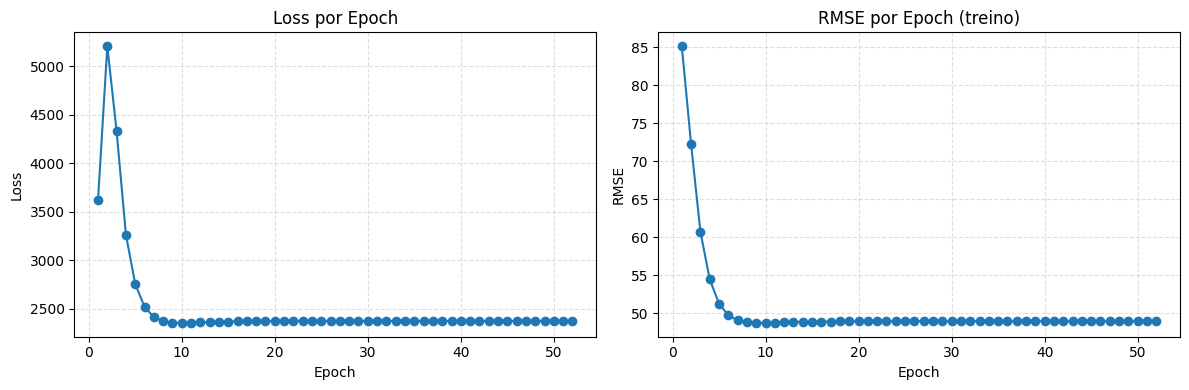

In [15]:
report = model.evaluate(X_test, y_test, plot_confusion=False, plot_roc=False, preds=preds_test)

# 8. Avaliação do modelo

O modelo de **VAE** apresentou desempenho **inferior ao baseline da média** em todas as métricas de regressão analisadas.

Em termos quantitativos, o modelo obteve um **MAE de aproximadamente 115,6** e **RMSE de 119,9**, enquanto o baseline — que simplesmente prevê a média do alvo — apresentou valores bem menores (**MAE ≈ 26,9** e **RMSE ≈ 31,9**). O **MAPE** reforça essa diferença, com **57,9%** para o modelo contra **14,4%** para o baseline, indicando uma imprecisão relativa cerca de quatro vezes maior. Além disso, o **MSE** elevado (14 374 vs. 1 020) e o **R² negativo (-13,08)** evidenciam que o modelo não conseguiu capturar a variabilidade dos dados, performando pior do que uma simples predição constante (baseline com R² = 0).

Esses resultados sugerem que o **VAE não conseguiu aprender adequadamente o padrão da variável-alvo**, possivelmente devido a problemas de **normalização**, **escala das variáveis**, **hiperparâmetros** (como taxa de aprendizado e número de épocas) ou até mesmo **excesso de complexidade da arquitetura**, o que pode ter levado a **overfitting**.

Durante o treinamento, foi implementada uma **estratégia de early stopping** com o objetivo de mitigar o overfitting. Essa técnica monitorava o **loss médio em uma janela deslizante de epochs**, interrompendo o treinamento quando a **diferença entre o loss atual e a média dessa janela** ficava abaixo de um **limiar (threshold)** definido. No entanto, essa estratégia **não foi eficaz em promover a generalização**, indicando que o modelo convergiu para uma solução local que não se traduz bem para novos dados.

Por fim, o **baseline de referência** consistiu em prever a **média da variável alvo** para todas as amostras, fornecendo uma base simples, porém sólida, de comparação.
O fato de o modelo VAE não superar esse baseline demonstra que o aprendizado foi ineficiente e que **revisões na arquitetura, nos dados de entrada e na função de perda** são necessárias para alcançar resultados mais satisfatórios.

